# Model Comparison, Hypothesis Testing & SHAP Analysis

**Part 1**: TimeSeriesSplit 5-fold CV for model comparison (AUC CI + rankings)  
**Part 2**: SHAP feature importance — CatBoost / XGBoost / LightGBM (temporal split, best params)

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import shap

from logistics_delay.data.loader import load_processed
from logistics_delay.features.engineering import XGB_CAT_COLS
from logistics_delay.models.train import temporal_split
from logistics_delay.models.evaluate import get_model
from logistics_delay.models.comparison import run_comparison, _create_model, _select_features
from logistics_delay.interpretation.shap_analysis import compute_shap_importance
from logistics_delay.utils.paths import FIGURES_SHAP, FIGURES_MODELS, TABLES_DIR, ensure_output_dirs

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
ensure_output_dirs()
print('[OK] Import complete')

In [ ]:
# ── Load pre-processed data (skip raw → engineer_features) ──
df = load_processed()
FEATURES_ENC = ['TRANSPORTATION_DISTANCE_IN_KM', 'vehicleType_enc', 'OriginLocation_Code_enc',
                'DestinationLocation_Code_enc', 'GpsProvider_enc', 'booking_prefix_enc',
                'origin_city_enc', 'dest_city_enc', 'customerID_enc', 'is_market',
                'supplier_is_large', 'start_weekday', 'start_month', 'min_kms_bin', 'planned_days_enc']
X_enc = df[FEATURES_ENC]
y = df['Answer']
print(f'Data shape: {df.shape}')
print(f'Delay rate: {y.mean()*100:.1f}%')

---
## 模型比较与假设检验

使用 **TimeSeriesSplit 5折** 时序交叉验证，Bootstrap 计算 AUC 置信区间，跨 fold 排名分析。

In [3]:
# ════════════════════════════════════════════════════════════════
#  1. TimeSeriesSplit 5 折时序交叉验证
# ════════════════════════════════════════════════════════════════
results = run_comparison(df, n_bootstrap=2000)

auc_ci = results['auc_ci']
rankings_df = results['rankings_df']
win_matrix = results['win_matrix']
fold_aucs = results['fold_aucs']

[comparison] TimeSeriesSplit(5) → 5 个时序 fold
[comparison] 模型: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
[comparison] Bootstrap: 2000

  [fold_1]  train=1144  test=1142  spw=8.1520
    LogisticRegression    AUC=0.3159  95%CI=[0.2404, 0.4121]
    DecisionTree          AUC=0.5000  95%CI=[0.5000, 0.5000]
    RandomForest          AUC=0.6266  95%CI=[0.5716, 0.6848]
    XGBoost               AUC=0.2901  95%CI=[0.2529, 0.3275]
    LightGBM              AUC=0.4450  95%CI=[0.3855, 0.5227]
    CatBoost              AUC=0.4926  95%CI=[0.3655, 0.6474]

  [fold_2]  train=2286  test=1142  spw=0.8201
    LogisticRegression    AUC=0.5326  95%CI=[0.3647, 0.7061]
    DecisionTree          AUC=0.6039  95%CI=[0.4652, 0.7435]
    RandomForest          AUC=0.6339  95%CI=[0.5055, 0.7643]
    XGBoost               AUC=0.7364  95%CI=[0.6335, 0.8285]
    LightGBM              AUC=0.6855  95%CI=[0.5649, 0.7873]
    CatBoost              AUC=0.6723  95%CI=[0.5064, 0

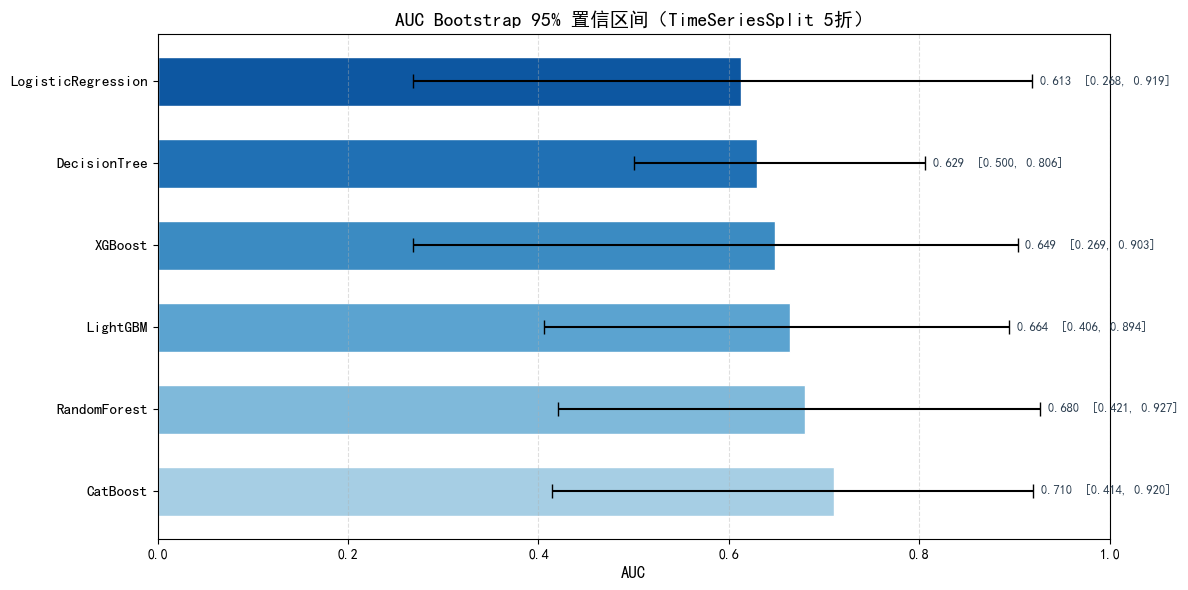

[OK] 已保存 → C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\models\auc_ci_comparison.png


In [4]:
# ════════════════════════════════════════════════════════════════
#  图 1: AUC 置信区间 — Bootstrap 95% CI
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))
names = auc_ci['model']
means = auc_ci['mean_auc']
lo = auc_ci['ci_lower']
hi = auc_ci['ci_upper']
err = [means - lo, hi - means]

colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(names)))
ax.barh(range(len(names)), means, xerr=err, color=colors, edgecolor='white',
        capsize=5, height=0.6)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel('AUC', fontsize=12)
ax.set_title('AUC Bootstrap 95% 置信区间（TimeSeriesSplit 5折）', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, 1)
for i, (m, l, u) in enumerate(zip(means, lo, hi)):
    ax.text(u + 0.008, i, f'{m:.3f}  [{l:.3f}, {u:.3f}]',
            va='center', fontsize=9, color='#2c3e50')
plt.tight_layout()
plt.savefig(FIGURES_MODELS / 'auc_ci_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[OK] 已保存 → {FIGURES_MODELS / "auc_ci_comparison.png"}')

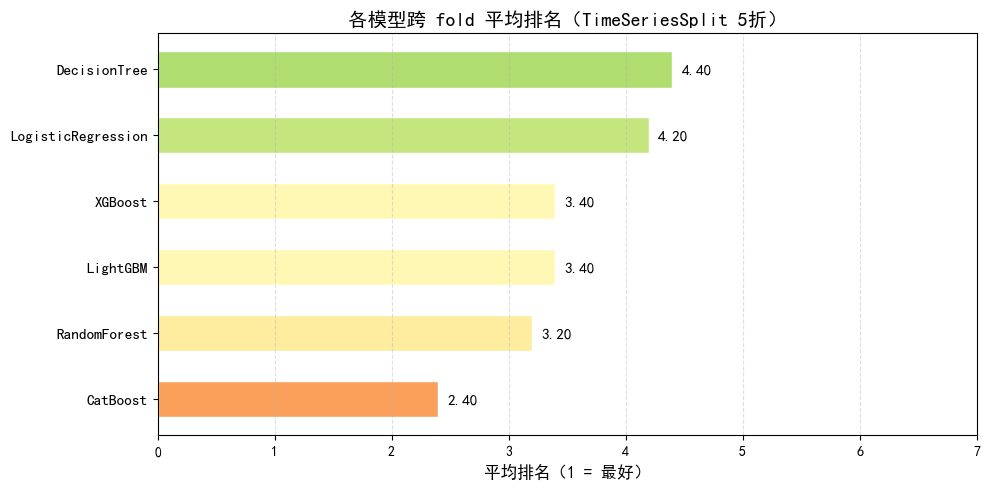

[OK] 已保存 → C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\models\model_avg_rank.png


In [5]:
# ════════════════════════════════════════════════════════════════
#  图 2: 模型平均排名（值越小越好）
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
avg = rankings_df['avg_rank'].sort_values()
n_m = len(avg)
norm = (avg.values - 1) / max(n_m - 1, 1)
colors = plt.cm.RdYlGn_r(1 - norm)
ax.barh(range(n_m), avg.values, color=colors, edgecolor='white', height=0.55)
ax.set_yticks(range(n_m))
ax.set_yticklabels(avg.index, fontsize=11)
ax.set_xlabel('平均排名（1 = 最好）', fontsize=12)
ax.set_title('各模型跨 fold 平均排名（TimeSeriesSplit 5折）', fontsize=14, fontweight='bold')
ax.set_xlim(0, n_m + 1)
ax.grid(axis='x', linestyle='--', alpha=0.4)
for i, v in enumerate(avg.values):
    ax.text(v + 0.08, i, f'{v:.2f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_MODELS / 'model_avg_rank.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[OK] 已保存 → {FIGURES_MODELS / "model_avg_rank.png"}')

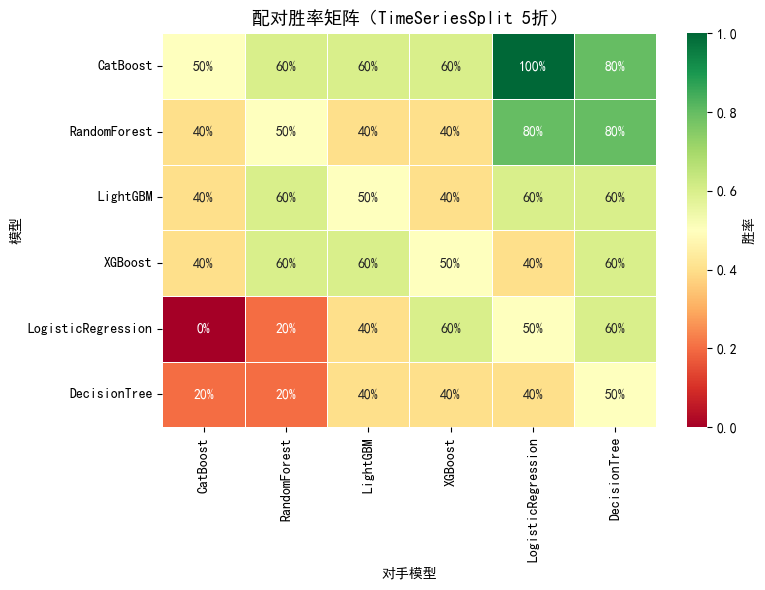

[OK] 已保存 → C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\models\win_matrix.png


In [6]:
# ════════════════════════════════════════════════════════════════
#  图 3: 配对胜率矩阵（行模型胜列模型的 fold 比例）
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
order = rankings_df.sort_values('avg_rank').index.tolist()
wm_sorted = win_matrix.loc[order, order]
sns.heatmap(wm_sorted, annot=True, fmt='.0%', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5, linecolor='white',
            cbar_kws={'label': '胜率'})
ax.set_title('配对胜率矩阵（TimeSeriesSplit 5折）', fontsize=13, fontweight='bold')
ax.set_ylabel('模型')
ax.set_xlabel('对手模型')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_MODELS / 'win_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[OK] 已保存 → {FIGURES_MODELS / "win_matrix.png"}')

In [7]:
# ════════════════════════════════════════════════════════════════
#  保存结果表格
# ════════════════════════════════════════════════════════════════
auc_ci.to_csv(TABLES_DIR / 'auc_ci_comparison.csv', index=False, encoding='utf-8-sig')
rankings_df.to_csv(TABLES_DIR / 'model_rankings.csv', encoding='utf-8-sig')
win_matrix.to_csv(TABLES_DIR / 'win_matrix.csv', encoding='utf-8-sig')

print('=' * 62)
print('  模型比较与假设检验完成')
print('=' * 62)
print(f'\nAUC 排名:')
for _, r in auc_ci.iterrows():
    print(f'  {r["model"]:<22s}  AUC={r["mean_auc"]:.4f}  '
          f'95%CI=[{r["ci_lower"]:.4f}, {r["ci_upper"]:.4f}]')
print(f'\n平均排名:')
for m, r in rankings_df.sort_values('avg_rank').iterrows():
    print(f'  {m:<22s}  平均排名={r["avg_rank"]:.2f}  第1名={r["rank_1"]}次')
print(f'\n已保存:')
print(f'  • {TABLES_DIR / "auc_ci_comparison.csv"}')
print(f'  • {TABLES_DIR / "model_rankings.csv"}')
print(f'  • {TABLES_DIR / "win_matrix.csv"}')

  模型比较与假设检验完成

AUC 排名:
  CatBoost                AUC=0.7103  95%CI=[0.4140, 0.9196]
  RandomForest            AUC=0.6796  95%CI=[0.4205, 0.9269]
  LightGBM                AUC=0.6642  95%CI=[0.4058, 0.8942]
  XGBoost                 AUC=0.6486  95%CI=[0.2686, 0.9031]
  DecisionTree            AUC=0.6294  95%CI=[0.5000, 0.8064]
  LogisticRegression      AUC=0.6131  95%CI=[0.2684, 0.9187]

平均排名:
  CatBoost                平均排名=2.40  第1名=1.0次
  RandomForest            平均排名=3.20  第1名=2.0次
  LightGBM                平均排名=3.40  第1名=0.0次
  XGBoost                 平均排名=3.40  第1名=2.0次
  LogisticRegression      平均排名=4.20  第1名=0.0次
  DecisionTree            平均排名=4.40  第1名=0.0次

已保存:
  • C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\tables\auc_ci_comparison.csv
  • C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\tables\model_rankings.csv
  • C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\

In [8]:
# ── Temporal split (80/20) ──
X_train_t, X_test_t, y_train_t, y_test_t, spw_t, cutoff = temporal_split(df, 'enc')
print(f'spw = {spw_t:.4f}')

# ── 树模型使用的 XGB 风格特征 ──
from logistics_delay.models.comparison import _create_model, _select_features
df_sorted = df.sort_values('trip_start_date').reset_index(drop=True)
si = int(len(df_sorted) * 0.8)
X_train_xgb = _select_features('XGBoost', df_sorted.loc[:si-1])
X_test_xgb  = _select_features('XGBoost', df_sorted.loc[si:])
y_train_t = df_sorted.loc[:si-1, 'Answer'].reset_index(drop=True)
y_test_t  = df_sorted.loc[si:, 'Answer'].reset_index(drop=True)
spw_t = (y_train_t == 0).sum() / (y_train_t == 1).sum()
print(f'spw (recalc) = {spw_t:.4f}')

[train] 时序划分: 分割点 2020-08-08
[train] 训练: 5483 条, 2019-03-18 ~ 2020-08-08
[train] 测试: 1371 条, 2020-08-08 ~ 2020-12-03
[train] scale_pos_weight = 0.3818
spw = 0.3818
spw (recalc) = 0.3818


---
## CatBoost SHAP — Temporal Split

CatBoost AUC (temporal): 85.96%

[shap] SHAP 重要性排名:
  1. planned_days_enc                     1.372906
  2. start_month                          0.306381
  3. TRANSPORTATION_DISTANCE_IN_KM        0.251417
  4. GpsProvider                          0.209058
  5. customerID                           0.191944
  6. booking_prefix                       0.102603
  7. OriginLocation_Code                  0.102429
  8. DestinationLocation_Code             0.087440
  9. start_weekday                        0.075372
  10. origin_city                          0.030309
  11. vehicleType                          0.013013
  12. supplier_is_large                    0.000000
  13. min_kms_bin                          0.000000
  14. is_market                            0.000000
  15. dest_city                            0.000000


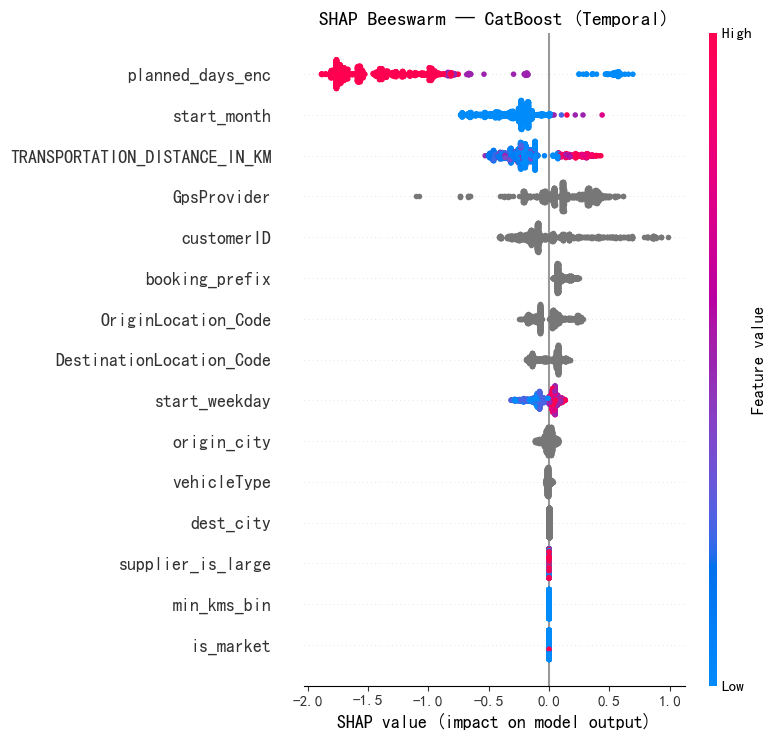

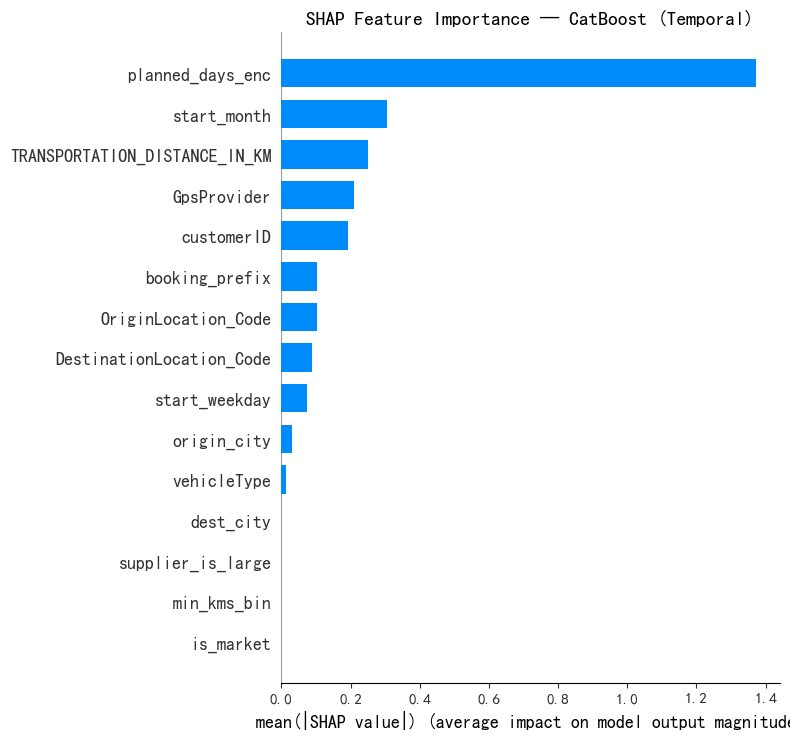

In [9]:
# ═══════════════════════════════════════════
#  1. CatBoost SHAP（最佳参数, 时序划分）
# ═══════════════════════════════════════════
cb = _create_model('CatBoost', spw_t)
cb.fit(X_train_xgb, y_train_t, cat_features=XGB_CAT_COLS)
cb_auc = roc_auc_score(y_test_t, cb.predict_proba(X_test_xgb)[:, 1])
print(f'CatBoost AUC (temporal): {cb_auc*100:.2f}%')
imp_cb, shap_v_cb, exp_cb = compute_shap_importance(cb, X_test_xgb, model_type='tree')

# Beeswarm
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_v_cb, X_test_xgb, plot_type='dot', show=False, max_display=15)
plt.title('SHAP Beeswarm — CatBoost (Temporal)', fontsize=14)
plt.tight_layout()
plt.savefig(str(FIGURES_SHAP / 'shap_dot_cb_time.png'), dpi=150, bbox_inches='tight')
plt.show()

# Bar
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_v_cb, X_test_xgb, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance — CatBoost (Temporal)', fontsize=14)
plt.tight_layout()
plt.savefig(str(FIGURES_SHAP / 'shap_bar_cb_time.png'), dpi=150, bbox_inches='tight')
plt.show()

XGBoost AUC (temporal): 81.63%

[shap] SHAP 重要性排名:
  1. planned_days_enc                     1.068306
  2. GpsProvider                          0.539095
  3. TRANSPORTATION_DISTANCE_IN_KM        0.488751
  4. start_month                          0.237315
  5. customerID                           0.187344
  6. OriginLocation_Code                  0.105302
  7. origin_city                          0.084325
  8. start_weekday                        0.080884
  9. DestinationLocation_Code             0.066671
  10. dest_city                            0.066398
  11. vehicleType                          0.038372
  12. booking_prefix                       0.011935
  13. min_kms_bin                          0.000077
  14. supplier_is_large                    0.000000
  15. is_market                            0.000000


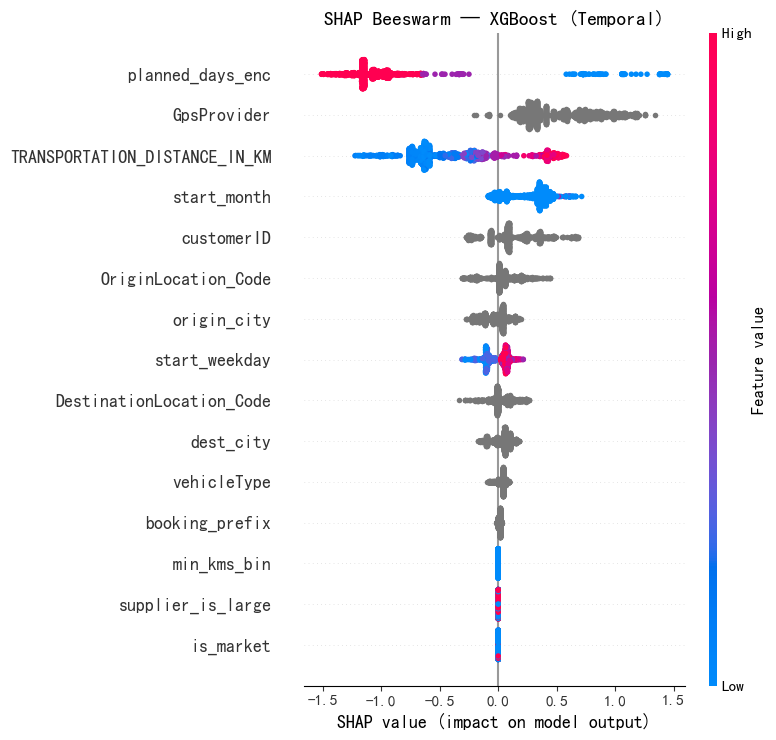

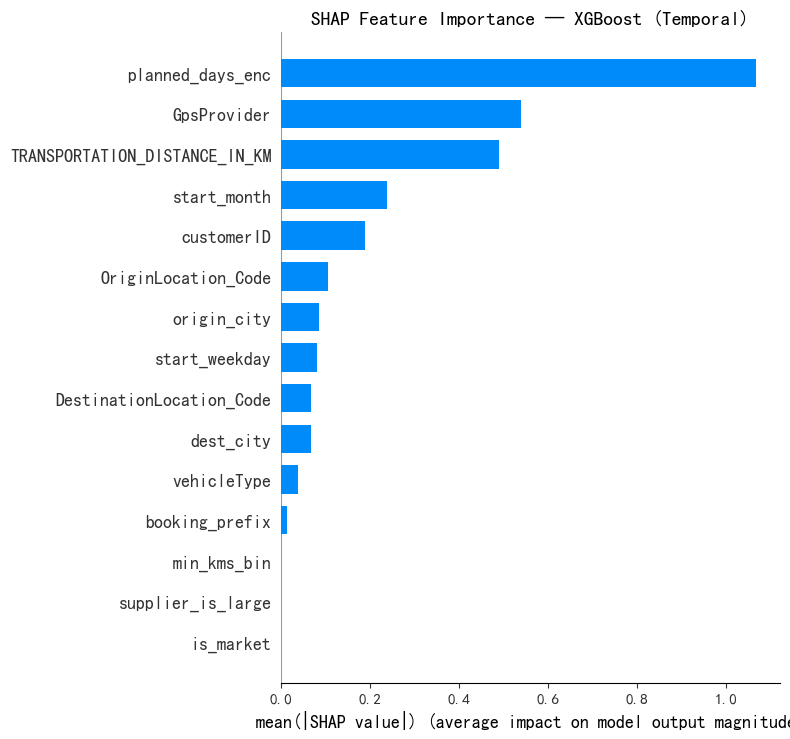

In [10]:
# ═══════════════════════════════════════════
#  2. XGBoost SHAP（最佳参数, 时序划分）
# ═══════════════════════════════════════════
xgb = _create_model('XGBoost', spw_t)
xgb.fit(X_train_xgb, y_train_t)
xgb_auc = roc_auc_score(y_test_t, xgb.predict_proba(X_test_xgb)[:, 1])
print(f'XGBoost AUC (temporal): {xgb_auc*100:.2f}%')
imp_xgb, shap_v_xgb, exp_xgb = compute_shap_importance(xgb, X_test_xgb, model_type='tree')

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_v_xgb, X_test_xgb, plot_type='dot', show=False, max_display=15)
plt.title('SHAP Beeswarm — XGBoost (Temporal)', fontsize=14)
plt.tight_layout()
plt.savefig(str(FIGURES_SHAP / 'shap_dot_xgb_time.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_v_xgb, X_test_xgb, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance — XGBoost (Temporal)', fontsize=14)
plt.tight_layout()
plt.savefig(str(FIGURES_SHAP / 'shap_bar_xgb_time.png'), dpi=150, bbox_inches='tight')
plt.show()

LightGBM AUC (temporal): 86.59%

[shap] SHAP 重要性排名:
  1. planned_days_enc                     1.449562
  2. TRANSPORTATION_DISTANCE_IN_KM        0.826748
  3. DestinationLocation_Code             0.593447
  4. GpsProvider                          0.465573
  5. OriginLocation_Code                  0.295479
  6. start_month                          0.146805
  7. start_weekday                        0.110429
  8. booking_prefix                       0.032567
  9. vehicleType                          0.016580
  10. origin_city                          0.008806
  11. dest_city                            0.005851
  12. min_kms_bin                          0.001431
  13. customerID                           0.001211
  14. supplier_is_large                    0.000000
  15. is_market                            0.000000


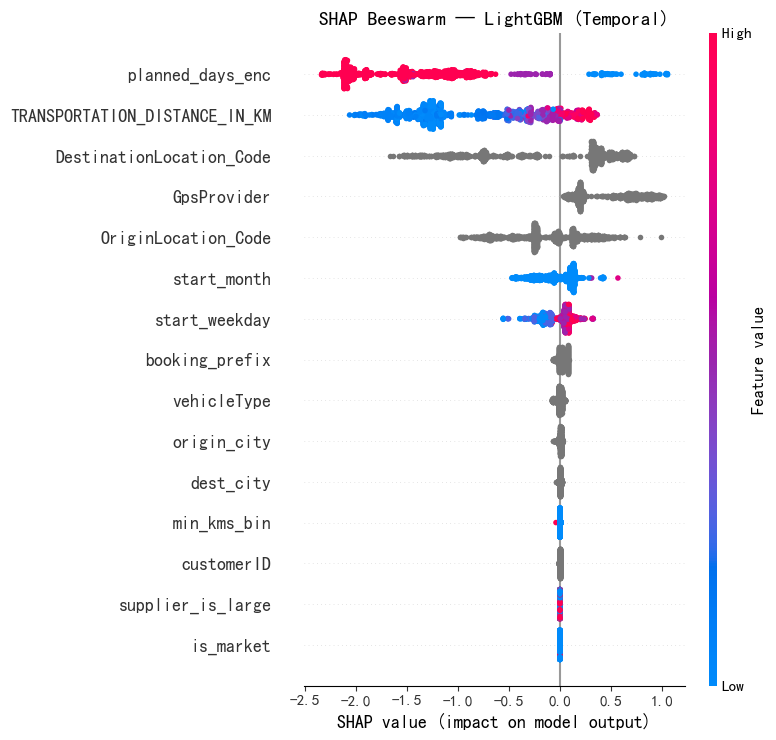

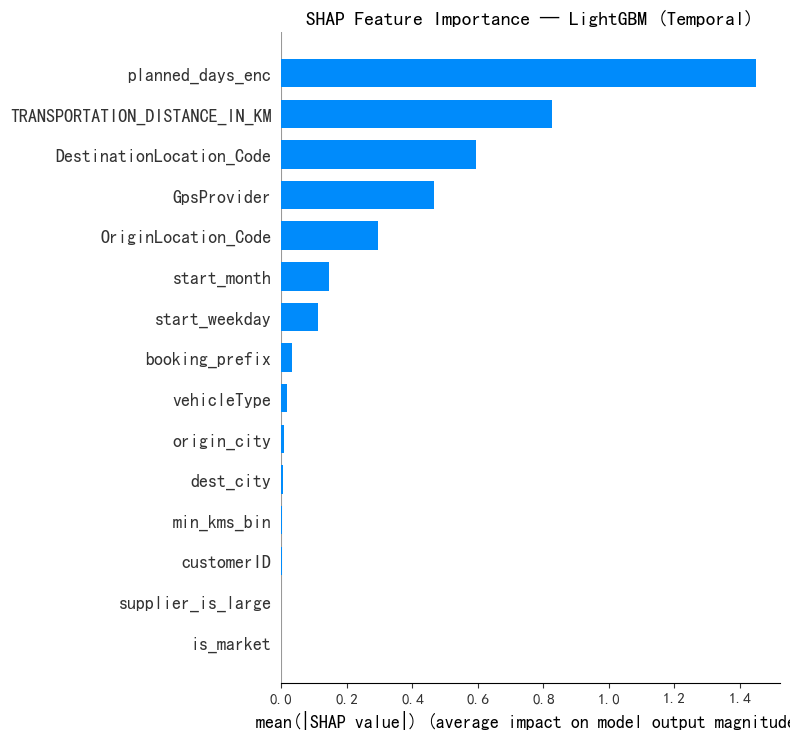

In [11]:
# ═══════════════════════════════════════════
#  3. LightGBM SHAP（最佳参数, 时序划分）
# ═══════════════════════════════════════════
lgb = _create_model('LightGBM', spw_t)
lgb.fit(X_train_xgb, y_train_t, categorical_feature=XGB_CAT_COLS)
lgb_auc = roc_auc_score(y_test_t, lgb.predict_proba(X_test_xgb)[:, 1])
print(f'LightGBM AUC (temporal): {lgb_auc*100:.2f}%')
imp_lgb, shap_v_lgb, exp_lgb = compute_shap_importance(lgb, X_test_xgb, model_type='tree')

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_v_lgb, X_test_xgb, plot_type='dot', show=False, max_display=15)
plt.title('SHAP Beeswarm — LightGBM (Temporal)', fontsize=14)
plt.tight_layout()
plt.savefig(str(FIGURES_SHAP / 'shap_dot_lgb_time.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_v_lgb, X_test_xgb, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance — LightGBM (Temporal)', fontsize=14)
plt.tight_layout()
plt.savefig(str(FIGURES_SHAP / 'shap_bar_lgb_time.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print('=' * 60)
print('  SHAP Analysis Complete — 3 Models (Temporal Split)')
print('=' * 60)
for name, auc in [('CatBoost', cb_auc), ('XGBoost', xgb_auc), ('LightGBM', lgb_auc)]:
    print(f'{name:10s}  AUC={auc*100:.2f}%')
print()
for name, imp in [('CatBoost', imp_cb), ('XGBoost', imp_xgb), ('LightGBM', imp_lgb)]:
    top3 = imp.head(3)['feature'].tolist()
    print(f'{name:10s}  Top-3: {top3}')

  SHAP Analysis Complete — 3 Models (Temporal Split)
CatBoost    AUC=85.96%
XGBoost     AUC=81.63%
LightGBM    AUC=86.59%

CatBoost    Top-3: ['planned_days_enc', 'start_month', 'TRANSPORTATION_DISTANCE_IN_KM']
XGBoost     Top-3: ['planned_days_enc', 'GpsProvider', 'TRANSPORTATION_DISTANCE_IN_KM']
LightGBM    Top-3: ['planned_days_enc', 'TRANSPORTATION_DISTANCE_IN_KM', 'DestinationLocation_Code']
